## KAPITEL 3 - Kodexempel och kunskapskontroller

13. Datasetet “hr_employee_data.xlsx” innehåller data kopplat till ett företags anställda. Gör en EDA och tillhörande analys, föreställ dig att ledningsgruppen på ett företag ska ta del av analysen. I denna uppgift ska
ingen ML-modellering göras (det kommer göras i nästa kapitel). Syftet är
dels att träna på att genomföra analyser dels att demonstrera hur mycket
man kan göra även utan ML-modellering.

HR Employee data - Exploratrory Data analysis

Syftet med denna analys är att förstå vilka faktorer som påverkar personalomstättningen samt indentifiera riskgrupper inomm ogranitionen.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")



In [6]:
df = pd.read_excel("hr_employee_data.xlsx")
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


## Dataöversikt
    Här börjar vi att förstå vår data och hur datasetets stuktur är.

In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  object 
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  object 
 10  salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(3)
memory usage: 1.3+ MB


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


## Datakvalitet
Kontrollerar saknade värden och dubbletter.

In [8]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

Datasetet innehåller inga datakvalitetsproblem.

## Personalomsättning
Vi med att analysera hur stor andel som lämnar företaget.

In [10]:
df["left"].value_counts(normalize=True)    

left
0    0.761917
1    0.238083
Name: proportion, dtype: float64

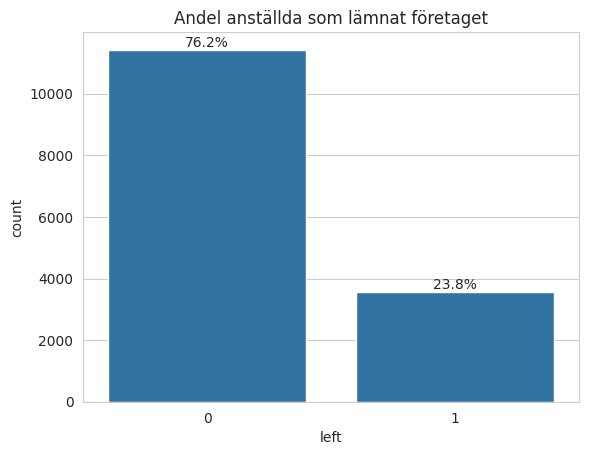

In [13]:
ax = sns.countplot(x='left', data=df)

total = len(df)

for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='bottom')

plt.title("Andel anställda som lämnat företaget")
plt.show()

Här ser man att 24% har lämnat företaget vilket tyder på ganska hög personalomsättning.

## Trivsel vs attrition
Vi analyserar nu om trivsel påverkar beslutet att lämna företaget.

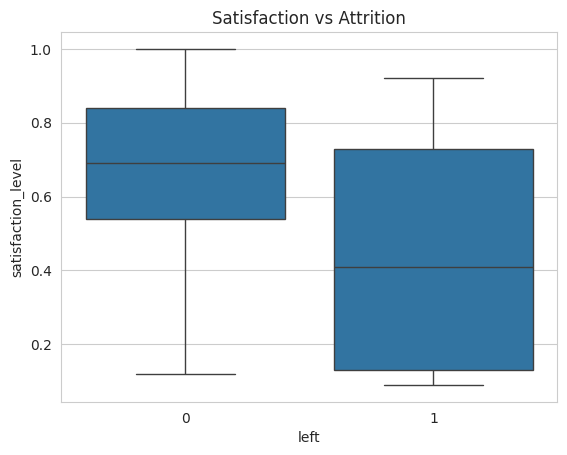

In [14]:
sns.boxplot(x='left', y='satisfaction_level', data=df)
plt.title("Satisfaction vs Attrition")
plt.show()

Anställda som lämnar företaget har betydligt lägre trivselnivå.
Detta är en av de starkaste indikatorerna på attrition.

## Arbetstid vs attrition


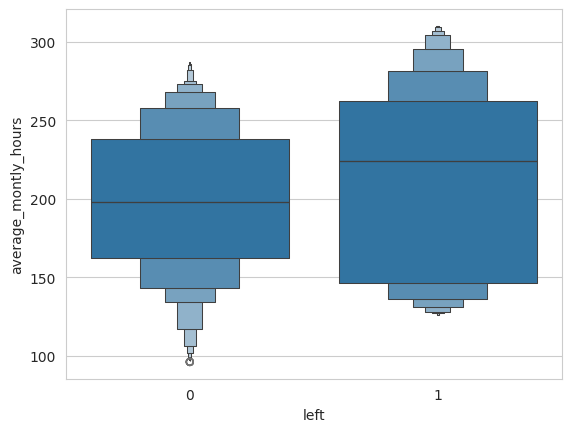

In [16]:
sns.boxenplot(x="left", y= "average_montly_hours", data=df)
plt.show()

Anställda som lämnar arbetar antingen väldigt lite eller väldigt mycket.
Detta kan indikera både underutnyttjande och överbelastning.

## Antal projekt vs Attrition


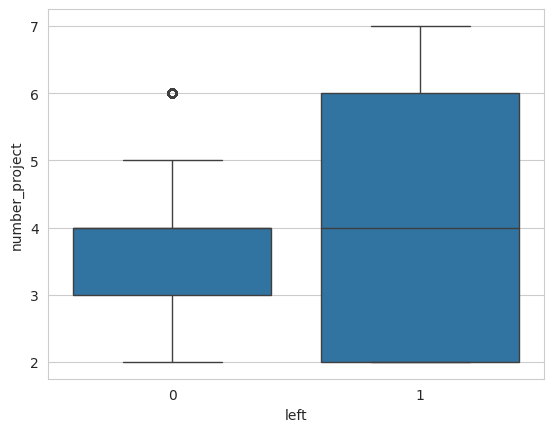

In [17]:
sns.boxplot(x='left', y='number_project', data=df)
plt.show()

Anställda med många projekt tenderar att lämna oftare,
vilket kan tyda på hög arbetsbelastning.

## Tid i företaget vs Attrition

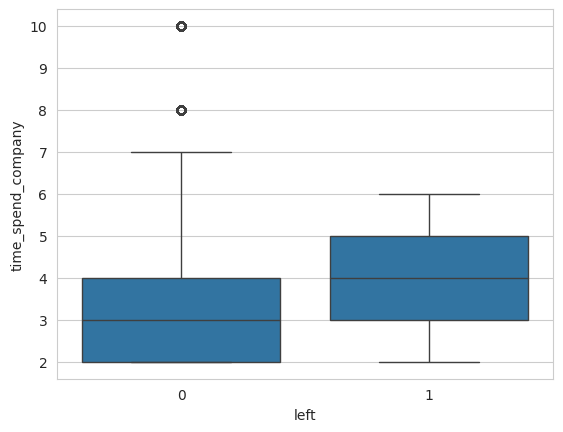

In [20]:
sns.boxplot(x="left", y="time_spend_company", data=df)
plt.show() 

Många som lämnar har arbetat 3–5 år,
vilket tyder på en kritisk period i anställningen.

## Lön vs Attrition


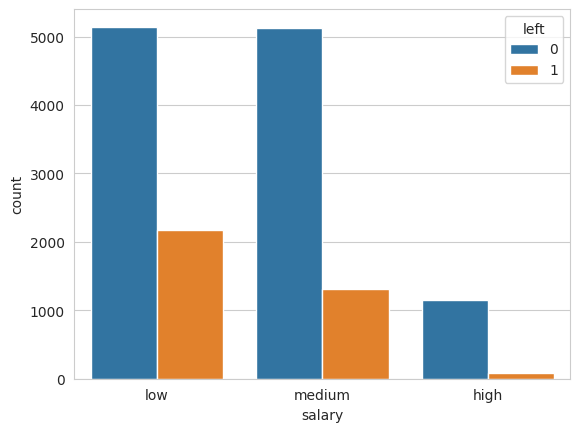

In [22]:
sns.countplot(x="salary", hue="left", data=df)
plt.show()

Anställda med låg lön lämnar företaget i högre utsträckning.

## Befordran vs Attrition 

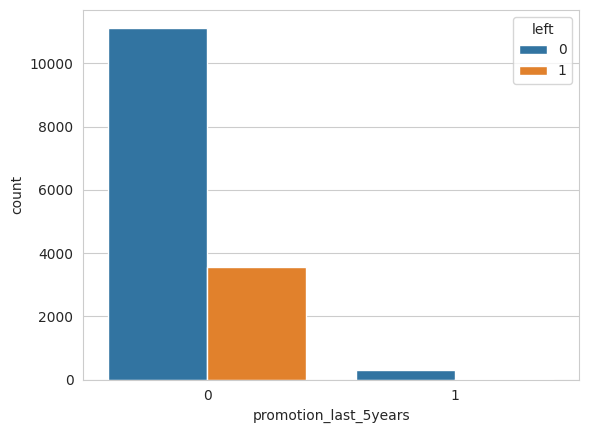

In [23]:
sns.countplot(x='promotion_last_5years', hue='left', data=df)
plt.show()

De flesta som lämnar har inte blivit befordrade,
vilket tyder på att karriärutveckling är viktig.

## Avdelning vs attrtion

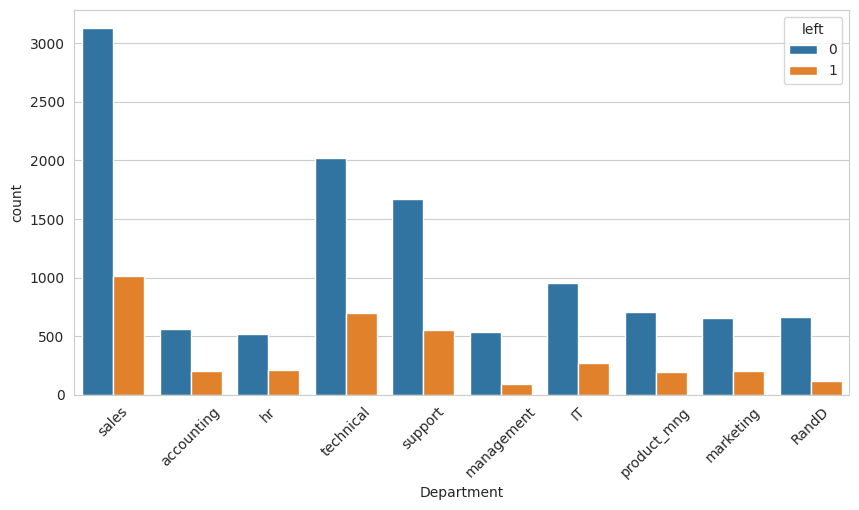

In [25]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Department', hue='left', data=df)
plt.xticks(rotation=45)
plt.show() 

Vissa avdelningar har betydligt högre personalomsättning,
vilket kan indikera organisatoriska problem.

## Insikter

- Låg trivsel är den starkaste faktorn bakom att anställda lämnar
- Hög arbetsbelastning (många projekt + många timmar) ökar risken
- Låg lön är kopplad till högre attrition
- Brist på befordran påverkar negativt
- Kritisk period: 3–5 år i företaget

## Rekommendationer

- Fokusera på trivsel och arbetsmiljö
- Minska överbelastning
- Se över löner i riskgrupper
- Skapa tydliga karriärvägar